In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import psutil, os

In [7]:
params2 = {
    # Reionisation
    'reio_parametrization':      'reio_jwst_popIII',
    'reio_jwst_popIII_logMvcut': np.float64(4.649424863615529),
    'reio_jwst_popIII_fesc':     np.float64(0.4474642233680556),
    'reio_jwst_popIII_a':        np.float64(0.12001351932783623),
    'reio_jwst_popIII_b':        np.float64(28.65350407901911),
    'reio_jwst_popIII_d':        np.float64(0.0901070227145518),
    'reio_jwst_popIII_zpop':     np.float64(44.84132649674628),
    'Phi_UV_file':               '../external/jwst_reio/Phi_UV.dat',
    # Cosmology
    'H0':        np.float64(59.30541236973364),
    'omega_b':   np.float64(0.01701793797958387),
    'omega_cdm': np.float64(0.13187745249158975),
    'A_s':       np.float64(4.6291278144171185e-09),
    'n_s':       np.float64(0.9891005274375169),
    'm_ncdm':    0.06,
    'k_pivot':   0.05,
    'T_cmb':     2.7255,
    'Omega_k':   0.0,
    # Neutrinos
    'N_ncdm': 1,
    'N_ur':   2.0328,
    # Recombination / BBN
    'YHe':           'BBN',
    'recombination': 'HyRec',
    'sBBN file':     '../external/bbn/sBBN_2017.dat',
    # Output
    'output':         'tCl pCl lCl',
    'non_linear':     'hmcode',
    'hmcode_version': 2020,
    'l_max_scalars':  2508,
    'lensing':        'yes',
}

In [20]:
params3 = {
    'omega_b': 0.01702,
    'omega_cdm': 0.13188,
    'H0': 59.3,
    'A_s': 4.629e-09,
    'n_s': 0.9891,
    'm_ncdm': 0.06,
    'k_pivot': 0.05,
    'T_cmb': 2.7255,
    'Omega_k': 0.0,
    'N_ncdm': 1,
    'N_ur': 2.0328,
    'reio_parametrization': 'reio_jwst_popIII',
    'reio_jwst_popIII_zpop': 44.84,
    'reio_jwst_popIII_logMvcut': 4.649,
    'reio_jwst_popIII_fesc': 0.447,
    'reio_jwst_popIII_a': 0.120,
    'reio_jwst_popIII_b': 28.65,
    'reio_jwst_popIII_d': 0.090,
    'YHe': 'BBN',
    'recombination': 'HyRec',
    'non_linear': 'hmcode',
    'hmcode_version': 2020,
    'output': 'tCl pCl lCl',
    'lensing': 'yes',
    'l_max_scalars': 2508,
    'sBBN file':  '/external/bbn/sBBN_2017.dat',
    'Phi_UV_file': '../external/jwst_reio/Phi_UV.dat',
}

In [23]:
cosmo2 = Class()
cosmo2.set(params3)
cosmo2.compute()

In [24]:
# Parameters from jwst_default.ini
params = {
    # Reionisation
    'reio_parametrization':       'reio_jwst_popIII',
    'reio_jwst_popIII_logMvcut':  6.4,
    'reio_jwst_popIII_fesc':      0.03,
    'reio_jwst_popIII_a':         0.15,
    'reio_jwst_popIII_b':         28.0,
    'reio_jwst_popIII_d':         0.034,
    'reio_jwst_popIII_zpop':      32.0,
    'Phi_UV_file':                '../external/jwst_reio/Phi_UV.dat',
    # Cosmology
    'h':         0.67,
    'omega_b':   0.022445,
    'omega_cdm': 0.13467,
    'A_s':       2.100549e-9,
    'n_s':       0.9660499,
    'k_pivot':   0.05,
    'Omega_k':   0.0,
    'T_cmb':     2.7255,
    'N_ur':      3.044,
    # Recombination / BBN
    'YHe':           'BBN',
    'recombination': 'HyRec',
    'sBBN file':     '/external/bbn/sBBN_2017.dat',
    # Perturbations
    'output':     'tCl,pCl,lCl',
    'lensing':    'yes',
    'non_linear': 'hmcode',
    'ic':         'ad',
    'modes':      's',
}

## Runs

In [25]:
cosmo = Class()
cosmo.set(params)
cosmo.compute()

In [26]:
derived = cosmo.get_current_derived_parameters(['tau_reio', 'z_reio', 'jwst_popIII_tau'])
print(f"tau_reio          = {derived['tau_reio']:.6f}")
print(f"z_reio            = {derived['z_reio']:.4f}")
print(f"jwst_popIII_tau   = {derived['jwst_popIII_tau']:.6f}  (kappa at zpop={params['reio_jwst_popIII_zpop']:.1f})")

tau_reio          = 0.052015
z_reio            = 7.6711
jwst_popIII_tau   = 0.052016  (kappa at zpop=32.0)


In [27]:
thermo = cosmo.get_thermodynamics()
z   = thermo['z']
xe  = thermo['x_e']
emk = thermo['exp(-kappa)']
g   = thermo['g [Mpc^-1]']
xHI = thermo.get('x_HI', None)  # only present for reio_jwst_popIII

kappa = -np.log(np.clip(emk, 1e-300, 1.0))

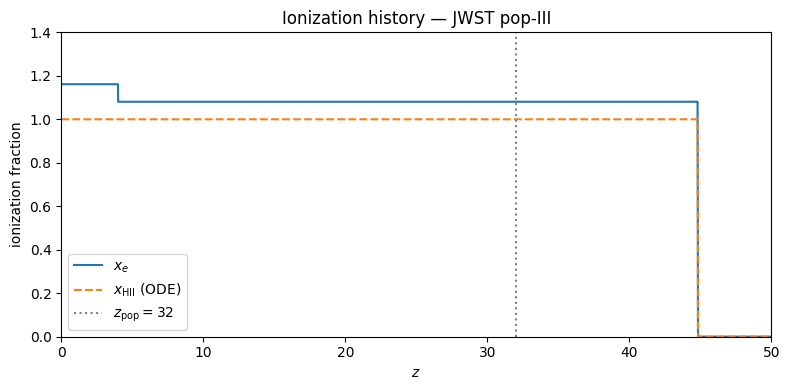

In [41]:
def plot_xe(cosmo, ax, label=None, zpop=None):
    thermo = cosmo.get_thermodynamics()
    z   = thermo['z']
    xe  = thermo['x_e']
    xHI = thermo.get('x_HI', None)

    ax.plot(z, xe, label=label or r'$x_e$')
    if xHI is not None:
        ax.plot(z, 1 - xHI, ls='--',
                label=(f'{label} ' if label else '') + r'$x_{\rm HII}$ (ODE)')
    if zpop is not None:
        ax.axvline(zpop, color='gray', ls=':', label=f'$z_{{\\rm pop}}={zpop:.0f}$')

    ax.set_xlabel('$z$')
    ax.set_ylabel('ionization fraction')
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 1.4)
    ax.legend()

fig, ax = plt.subplots(figsize=(8, 4))
plot_xe(cosmo2, ax, zpop=params.get('reio_jwst_popIII_zpop'))
ax.set_title('Ionization history — JWST pop-III')
plt.tight_layout()
plt.show()

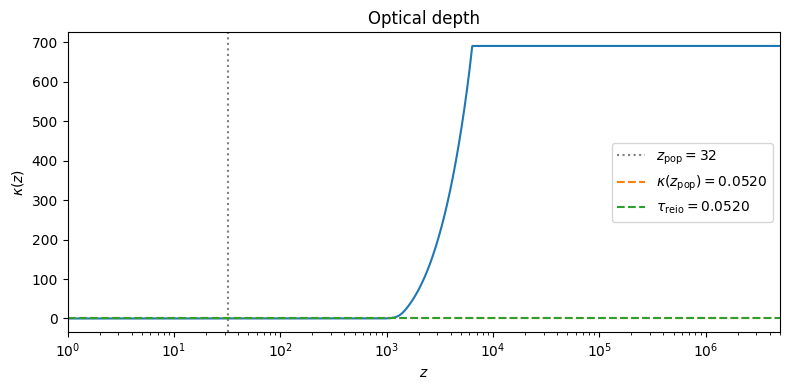

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, kappa)
ax.axvline(params['reio_jwst_popIII_zpop'], color='gray', ls=':', label=f"$z_{{\\rm pop}}={params['reio_jwst_popIII_zpop']:.0f}$")
ax.axhline(derived['jwst_popIII_tau'], color='C1', ls='--',
           label=rf"$\kappa(z_{{\rm pop}})={derived['jwst_popIII_tau']:.4f}$")
ax.axhline(derived['tau_reio'], color='C2', ls='--',
           label=rf"$\tau_{{\rm reio}}={derived['tau_reio']:.4f}$")
ax.set_xlabel('$z$')
ax.set_ylabel(r'$\kappa(z)$')
ax.set_xscale('log')
ax.set_xlim(1, z.max())
ax.legend()
ax.set_title('Optical depth')
plt.tight_layout()
plt.show()

In [38]:
cls_l   = cosmo.lensed_cl()
cls_r   = cosmo.raw_cl()
ell     = cls_l['ell']
fac     = ell * (ell + 1) / (2 * np.pi) * (cosmo.T_cmb() * 1e6) ** 2

DlTT = fac * cls_l['tt']
DlEE = fac * cls_l['ee']
DlTE = fac * cls_l['te']
DlBB = fac * cls_l['bb']

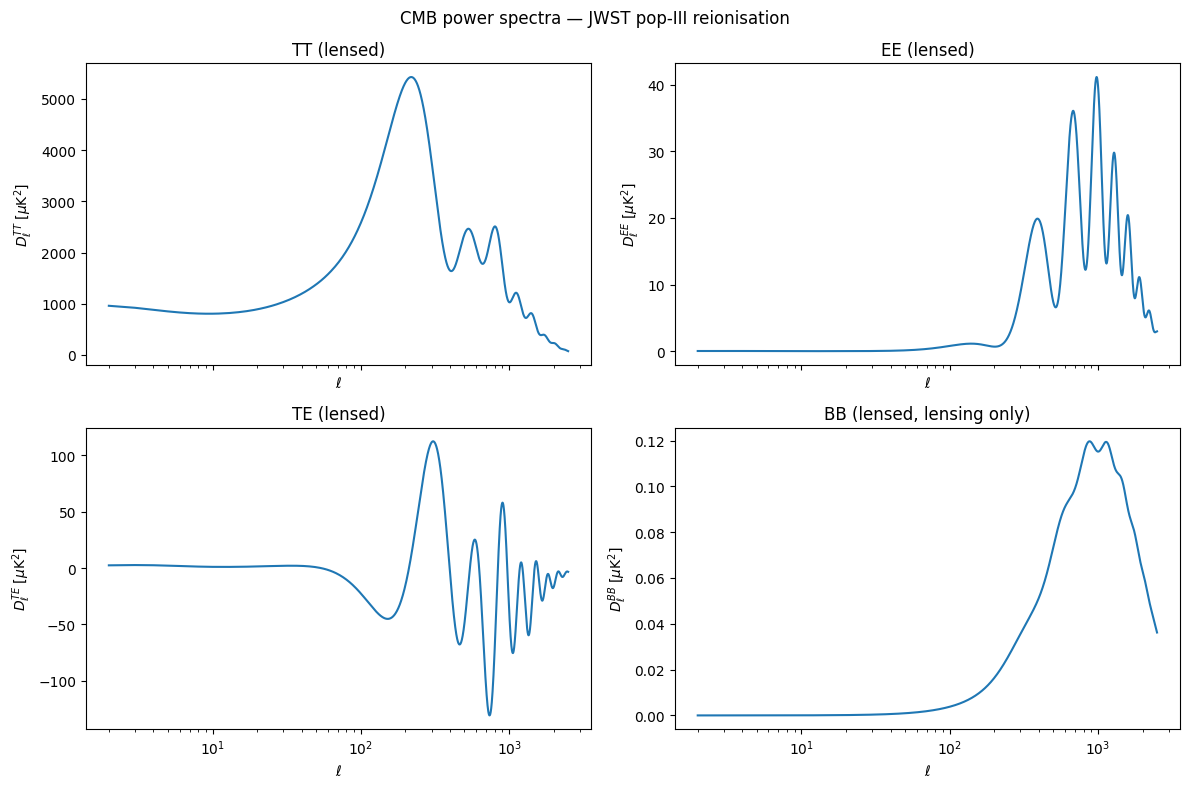

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
l2 = ell[2:]

axes[0, 0].plot(l2, DlTT[2:])
axes[0, 0].set_ylabel(r'$D_\ell^{TT}\;[\mu\mathrm{K}^2]$')
axes[0, 0].set_title('TT (lensed)')

axes[0, 1].plot(l2, DlEE[2:])
axes[0, 1].set_ylabel(r'$D_\ell^{EE}\;[\mu\mathrm{K}^2]$')
axes[0, 1].set_title('EE (lensed)')

axes[1, 0].plot(l2, DlTE[2:])
axes[1, 0].set_ylabel(r'$D_\ell^{TE}\;[\mu\mathrm{K}^2]$')
axes[1, 0].set_title('TE (lensed)')

axes[1, 1].plot(l2, DlBB[2:])
axes[1, 1].set_ylabel(r'$D_\ell^{BB}\;[\mu\mathrm{K}^2]$')
axes[1, 1].set_title('BB (lensed, lensing only)')

for ax in axes.flat:
    ax.set_xlabel(r'$\ell$')
    ax.set_xscale('log')

fig.suptitle('CMB power spectra — JWST pop-III reionisation')
plt.tight_layout()
plt.show()